In [88]:
from build import Population, Config
from build.models.base import Sequential, Linear, NeatModule
from build.util.datetime import eta, clock
from build.optim.scheduler import CosineAnnealing

from torch import Tensor
from numpy import ndarray as CPUArray

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
import numpy as np
from numba.core.errors import NumbaPerformanceWarning

In [89]:
# Suppress NumbaPerformanceWarning
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

In [90]:
torch.set_printoptions(threshold=10)

In [91]:
device = 'cuda'
dtype  = torch.float64

In [92]:
genome_num = 500

In [93]:
config = Config()
config.genome.init_type = 'normal'
config.genome.weight_init_mean = 0
config.genome.weight_init_std = 1
config.genome.weight_min_value = -np.pi * 10
config.genome.weight_max_value = np.pi * 10
config.genome.weight_mutate_power = 0.8
config.genome.weight_mutate_rate = 0.7
config.reproduction.min_species_size = genome_num
config.reproduction.elitism = 100
config.reproduction.survival_threshold = 0.01
config.reproduction.purge = 1
config.species.compatibility_threshold = 4
config.save()
config.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration default-neat_config.txt
fitness_criterion         = max
fitness_threshold         = 100
pop_size                  = 10000
reset_on_extinction       = True
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
weight_init_mean          = 0
weight_init_std           = 1
weight_max_value          = 31.41592653589793
weight_min_value          = -31.41592653589793
weight_mutate_power       = 0.8
weight_mutate_rate        = 0.7
weight_replace_rate       = 0.05
bias_init_mean            = 0.0
bias_init_std             = 1
bias_max_value            = 31.4199999999

In [94]:
batch_size  = 8
seq_len     = 8
input_dims  = 2
output_dims = 1
embedding   = 64
differential = True
layers      = 1
heads       = 1
bias        = False

In [95]:
records = 100

In [96]:
upper   = 10
divider = upper + seq_len

In [97]:
# def create(genomes_num: int, low: int, high: int, records, seq_len: int, size: int, inv=True):
#     inp = torch.stack([
#         torch.stack([
#             torch.arange(i, i+(size if not inv else seq_len)) for i in torch.randint(low, high, (seq_len if not inv else size,))
#         ]) for _ in range(records)
#     ])
#     if inv:
#         inp = inp.mT
#     out = inp.clone() + 1
#     return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape) / divider, \
#            out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape) / divider

def create(genomes_num: int):
    inp = torch.tensor([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ])
    out = torch.tensor([
        [0],
        [1],
        [1],
        [0],
    ])
    return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape), \
           out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape)

In [98]:
train_inp, train_out = create(genome_num)

In [99]:
train_inp.shape, train_out.shape

(torch.Size([500, 4, 2]), torch.Size([500, 4, 1]))

In [100]:
train_inp

tensor([[[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        ...,

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]]], device='cuda:0', dtype=torch.float64)

In [101]:
train_out

tensor([[[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]],

        ...,

        [[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]]], device='cuda:0', dtype=torch.float64)

In [102]:
def model_size(model: NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [103]:
linear = Sequential(
    Linear(input_dims, embedding, bias, device=device, dtype=dtype),
    nn.SiLU(),
    Linear(embedding, output_dims, bias, device=device, dtype=dtype),
    nn.Tanh(),
)
# linear = Linear(input_dims, output_dims, bias, device, dtype)
population = Population(genome_num, linear, config)
linear, model_size(linear)


Initialized genomes in  in 0.02s

Created distances cache in 0.18 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.18 s
Mean genetic distance 0.550, standard deviation 0.425, with 1 species


(Sequential[NeatModule](
 	(0): Linear[NeatModule](inputs=2, outputs=64, bias=False)
 	(1): SiLU()
 	(2): Linear[NeatModule](inputs=64, outputs=1, bias=False)
 	(3): Tanh()
 ),
 96000)

In [104]:
linear.modules

<bound method Module.modules of Sequential[NeatModule](
	(0): Linear[NeatModule](inputs=2, outputs=64, bias=False)
	(1): SiLU()
	(2): Linear[NeatModule](inputs=64, outputs=1, bias=False)
	(3): Tanh()
)>

In [105]:
# arr = np.round(linear.modules_list[0].weights.data.cpu().numpy(), 4)
# arr[..., 0]

In [106]:
lin_unit = linear.modules_list[0]
torch.sum(lin_unit.weights.data > 0), torch.sum(lin_unit.weights.data < 0), torch.sum(lin_unit.weights.data == 0)

(tensor(32250, device='cuda:0'),
 tensor(31750, device='cuda:0'),
 tensor(0, device='cuda:0'))

In [107]:
g_idx = np.random.randint(linear.genome_num)
o, (w, b) = lin_unit(train_inp, verbose=True)
o, w, b = o[g_idx].cpu().numpy(), w[g_idx].cpu().numpy(), b # [g_idx].cpu().numpy()
g_idx

153

In [108]:
train_inp[g_idx].cpu().numpy()

array([[0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 1.]])

In [109]:
o

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.87720104, -0.03514072,  0.48789463,  0.82540595,  1.

In [110]:
w

array([[ 0.74847555,  0.1107411 ,  0.27726945,  0.23669385, -0.71354443,
        -0.39709258, -0.37674506,  2.5062268 , -0.23258232, -1.90618286,
         0.77462046, -1.10381481, -0.68634359,  1.20355097,  0.08926674,
         0.94375568, -0.34224518,  0.10512998,  1.00470032, -0.37314068,
        -0.26173616, -1.19472832,  0.19851293,  1.43510774, -0.14667239,
         0.81595976, -1.92690659,  0.86840233,  0.78113111,  1.87204448,
        -1.44093882, -0.78729033, -0.26928471, -0.28003428,  2.21512778,
        -1.29525986,  0.37629222,  0.11894188,  0.26886614, -1.78545533,
        -0.33101433,  0.61718122, -0.72303541, -1.03923635, -1.03139197,
        -0.77458431,  3.6344887 , -0.50654721,  0.2007233 , -0.25764846,
         2.39721869, -2.15312569, -0.76309889, -1.95517608, -2.31086197,
         1.08410786,  0.07857985,  0.93662053,  1.18723299,  0.27476561,
         0.08637488, -0.36247946,  2.20590586, -0.73786673],
       [ 0.87720104, -0.03514072,  0.48789463,  0.82540595,  1.

In [111]:
b

In [112]:
outputs = linear(train_inp)
outputs.shape

torch.Size([500, 4, 1])

In [113]:
outputs[0]

tensor([[ 0.0000],
        [-0.5372],
        [ 0.9209],
        [ 0.9795]], device='cuda:0', dtype=torch.float64)

In [114]:
for i, out in enumerate(train_out[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.], device='cuda:0', dtype=torch.float64)
Record 2: torch.Size([1])
tensor([1.], device='cuda:0', dtype=torch.float64)
Record 3: torch.Size([1])
tensor([1.], device='cuda:0', dtype=torch.float64)
Record 4: torch.Size([1])
tensor([0.], device='cuda:0', dtype=torch.float64)


In [115]:
for i, out in enumerate(outputs[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.], device='cuda:0', dtype=torch.float64)
Record 2: torch.Size([1])
tensor([-0.5372], device='cuda:0', dtype=torch.float64)
Record 3: torch.Size([1])
tensor([0.9209], device='cuda:0', dtype=torch.float64)
Record 4: torch.Size([1])
tensor([0.9795], device='cuda:0', dtype=torch.float64)


In [116]:
# def plot_attention(attention: list[Tensor], genome_index: int, layer_index: int, records: int, randomize=False, size=(1440, 1080), inverse=False, cmap='bone_r'):
#     attention: Tensor = attention[layer_index]
#     g, b, heads, q, k = attention.shape
#     fig, axes = plt.subplots(records, heads, figsize=(size[0]*0.01, size[1]*0.01))
#     if isinstance(axes, CPUArray):
#         axes = axes.flatten()
#     else:
#         axes = [axes]
#     if inverse:
#         axes = axes[::-1]
#     x = 0
#     if not randomize:
#         indices = torch.arange(records)
#     else:
#         indices = torch.randperm(attention.size(1))[:records]
#     for i, record in enumerate(torch.index_select(attention[genome_index], 0, indices.to(device))):
#         for j, att_head in enumerate(record):
#             if q == 1:
#                 att_head = att_head.expand(k, k)
#             axes[x].imshow(att_head.float().cpu(), cmap=cmap)
#             x += 1
#     plt.show()
#     return att_head

In [117]:
def accuracy(prediction: Tensor, target: Tensor, error=0.01):
    prediction, target = prediction*divider, target*divider
    total: Tensor = ((prediction >= target*(1-error)) & (prediction <= target*(1+error))) == True
    dims = tuple(range(1, train_out.ndim))
    size = np.prod(total.shape[1:])
    acc = (total.float().count_nonzero(dims) / size)
    print(acc.shape)
    acc = acc.max().cpu().item()
    return np.round(acc, 4) * 100

In [118]:
accuracy(linear(train_inp), train_out)

torch.Size([500])


75.0

In [119]:
def evaluation(population: Population, **options):
    global train_inp, train_out
    if linear.genome_num != train_inp.shape[0]:
        train_inp, train_out = create(linear.genome_num)

    losses_plot: list[float] = options['losses']

    out = linear(train_inp)
    dims = tuple(range(1, train_out.ndim))
    losses = torch.mean((train_out-out) ** 2, dims)
    losses_plot.append(losses.min().cpu().item())
    scores = (1 - losses).cpu().numpy()

    for score, gid in zip(scores, linear.mapping.keys()):
        population.genomes[gid].fitness = score

In [120]:
def train(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    losses: list[float] = []

    try:
        population.run(evaluation, epochs, losses=losses, verbose=3)
    except KeyboardInterrupt as e:
        print(e)

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    torch.cuda.empty_cache()
    return losses

In [121]:
len(linear.mapping), len(population.genomes)

(500, 500)

In [122]:
population.get_mapping()

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 9: 9,
 10: 10,
 11: 11,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 16: 16,
 17: 17,
 18: 18,
 19: 19,
 20: 20,
 21: 21,
 22: 22,
 23: 23,
 24: 24,
 25: 25,
 26: 26,
 27: 27,
 28: 28,
 29: 29,
 30: 30,
 31: 31,
 32: 32,
 33: 33,
 34: 34,
 35: 35,
 36: 36,
 37: 37,
 38: 38,
 39: 39,
 40: 40,
 41: 41,
 42: 42,
 43: 43,
 44: 44,
 45: 45,
 46: 46,
 47: 47,
 48: 48,
 49: 49,
 50: 50,
 51: 51,
 52: 52,
 53: 53,
 54: 54,
 55: 55,
 56: 56,
 57: 57,
 58: 58,
 59: 59,
 60: 60,
 61: 61,
 62: 62,
 63: 63,
 64: 64,
 65: 65,
 66: 66,
 67: 67,
 68: 68,
 69: 69,
 70: 70,
 71: 71,
 72: 72,
 73: 73,
 74: 74,
 75: 75,
 76: 76,
 77: 77,
 78: 78,
 79: 79,
 80: 80,
 81: 81,
 82: 82,
 83: 83,
 84: 84,
 85: 85,
 86: 86,
 87: 87,
 88: 88,
 89: 89,
 90: 90,
 91: 91,
 92: 92,
 93: 93,
 94: 94,
 95: 95,
 96: 96,
 97: 97,
 98: 98,
 99: 99,
 100: 100,
 101: 101,
 102: 102,
 103: 103,
 104: 104,
 105: 105,
 106: 106,
 107: 107,
 108: 108,
 109: 109,
 110: 110,

In [123]:
scheduler = CosineAnnealing(config, 100, 10, 0.01, True, True)


 ****** Running generation 1 ****** 

executing fitness function <function evaluation at 0x0000028816C2F9C0> on population, skip-enabled=False
updating population

Population's average fitness: -0.12434 std_dev: 0.68299
Best fitness: 0.98557 - species 1 - id 418
Average adjusted fitness: 0.504

Spawned new genomes in  in 0.05s

Created distances cache in 0.16 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.16 s
Mean genetic distance 0.506, standard deviation 0.460, with 1 species
Population of 500 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
   2    0   500       --       --     0
Total extinctions: 0
Generation time: 0.546 sec

 ****** Running generation 2 ****** 

executing fitness function <function evaluation at 0x0000028816C2F9C0> on population, skip-enabled=False
updating population

Population's average fitness: -0.00329 std_dev: 0.71846
B

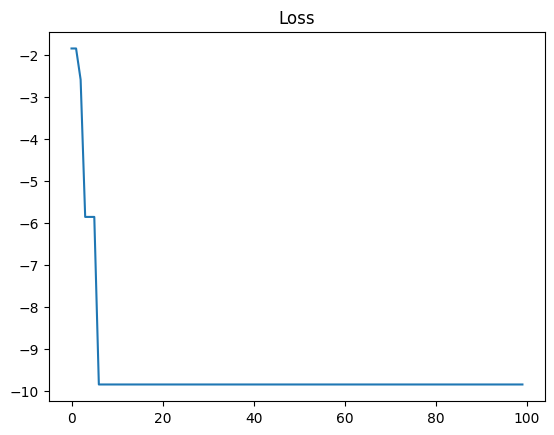

In [124]:
train(100);

In [125]:
params = linear.neat_parameters()
len(params)

2

In [126]:
param_index = np.random.randint(len(params))
param = params[param_index]
param_index

1

In [133]:
linear.neat_modules()[0].mapping

In [127]:
param.data[param_index]

tensor([[-0.9604],
        [-1.4121],
        [-1.0034],
        ...,
        [ 1.3748],
        [-0.9747],
        [-1.5560]], device='cuda:0', dtype=torch.float64)

In [128]:
linear.mapping

{2618: 0,
 7290: 1,
 16348: 2,
 28615: 3,
 10249: 4,
 25147: 5,
 23150: 6,
 16223: 7,
 17269: 8,
 18660: 9,
 6588: 10,
 39028: 11,
 36617: 12,
 8198: 13,
 1339: 14,
 1992: 15,
 7305: 16,
 29120: 17,
 38723: 18,
 23772: 19,
 14106: 20,
 24146: 21,
 20776: 22,
 39198: 23,
 29657: 24,
 22798: 25,
 22906: 26,
 7389: 27,
 6059: 28,
 38874: 29,
 6696: 30,
 20057: 31,
 11036: 32,
 31997: 33,
 21485: 34,
 34459: 35,
 26376: 36,
 5356: 37,
 24100: 38,
 3060: 39,
 30758: 40,
 33601: 41,
 36468: 42,
 6474: 43,
 27866: 44,
 7833: 45,
 31868: 46,
 10732: 47,
 20774: 48,
 7405: 49,
 8360: 50,
 21104: 51,
 22637: 52,
 11978: 53,
 3646: 54,
 32305: 55,
 32117: 56,
 22739: 57,
 6657: 58,
 21210: 59,
 21305: 60,
 37013: 61,
 22773: 62,
 9523: 63,
 26654: 64,
 37383: 65,
 28740: 66,
 18041: 67,
 10695: 68,
 3508: 69,
 14455: 70,
 25756: 71,
 4026: 72,
 33175: 73,
 20890: 74,
 16086: 75,
 36216: 76,
 36583: 77,
 2139: 78,
 37555: 79,
 18252: 80,
 19611: 81,
 8694: 82,
 33202: 83,
 25702: 84,
 10904: 85,
 

In [129]:
len(linear.mapping), len(population.genomes), linear.genome_num

(500, 500, 500)

In [130]:
best_key = population.best_genome.key if population.best_genome and population.best_genome.key in population.genomes is not None else None
best_key

2618

In [131]:
# accuracy(linear(eval_inp, keys=best_key), eval_out), \
accuracy(linear(train_inp, keys=best_key), train_out)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
train_inp.shape

In [ ]:
outputs = linear(train_inp, keys=best_key)
if best_key is not None:
    outputs = outputs[linear.mapping[best_key]].unsqueeze(0)

In [ ]:
outputs.shape

In [ ]:
for i, out in enumerate(train_out[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

In [ ]:
for i, out in enumerate(outputs[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

In [ ]:
linear2 = nn.Sequential(
    nn.Linear(input_dims, embedding, bias, device=device, dtype=dtype),
    nn.SiLU(),
    nn.Linear(embedding, output_dims, bias, device=device, dtype=dtype),
    nn.SiLU(),
)
linear2

In [ ]:
optimizer = optim.AdamW(linear2.parameters(), 1e-2)

In [ ]:
def train2(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    linear2.requires_grad_(True)
    # attention.causal_mask = False

    losses = []
    ts, ud, ut = clock.perf_counter(), 0, epochs

    dims = tuple(range(1, train_out.ndim))
    best_loss = F.mse_loss(linear2(train_inp), train_out)
    best_epoch = -1
    save_state = linear2.state_dict()
    for epoch in range(epochs):
        try:
            optimizer.zero_grad()
            test_actv = linear2(train_inp)
            loss = F.mse_loss(test_actv, train_out)
            loss.backward()
            optimizer.step()

            losses.append(loss.cpu().item())

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = linear2.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item(): .4e} | "
                            f"best={best_loss.cpu().item(): .4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break

    linear2.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    linear2.requires_grad_(False)
    torch.cuda.empty_cache()
    return losses

In [ ]:
train2(10000, checkpoints=1);

In [ ]:
# linear2.modules_list[0].weights[best_key]

In [ ]:
# linear2.modules_list[0].biases[best_key]

In [ ]:
outputs = linear2(train_inp) #, keys=best_key)
# if best_key is not None:
#     outputs = outputs[linear2.mapping[best_key]].unsqueeze(0)
for i, out in enumerate(outputs[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

In [ ]:
# plot_attention(att, 0, 0, 3, True, size=(1080, 720))

In [ ]:
plt.imshow(torch.arange(10*10).view(10, 10), cmap='bone_r')
torch.arange(10*10).view(10, 10)